# Exploratory Data Analysis & Data Wrangling

## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

## ¿Qué es EDA? El contrato antes del modelo

El Análisis Exploratorio de Datos no es un paso opcional ni una cortesía académica: es el contrato de confianza que un científico de datos firma con sus datos antes de tomar cualquier decisión analítica. John W. Tukey lo definió en 1977 como **"una actitud y una flexibilidad, no un paquete de técnicas."** La clave está en que EDA responde preguntas que aún no sabemos que teníamos.

Un dataset nunca llega limpio. Siempre llega con historia: sistemas heredados, errores de digitación, integraciones fallidas, campos opcionales que nadie llenó, cambios de esquema no documentados. Ignorar esa historia y modelar directamente sobre datos crudos es construir sobre arena: el modelo aprenderá ruido, sesgos y artefactos, confundiéndolos con señal real.

### EDA vs. CDA: dos modos del análisis estadístico

| Modo | Pregunta central | Cuándo aplicar |
|------|-----------------|----------------|
| **EDA — Exploratorio** | ¿Qué hay aquí? | Siempre primero |
| **CDA — Confirmatorio** | ¿Es esto verdad? | Después del EDA |

El EDA genera hipótesis. El CDA las valida. Saltarse el EDA equivale a validar hipótesis que nunca se formularon conscientemente.

### Los 5 pasos del proceso EDA

1. **Explorar la estructura** — ¿qué forma tienen los datos?
2. **Auditar la calidad** — ¿qué problemas tienen?
3. **Resolver los problemas** — limpieza y transformación
4. **Describir estadísticamente** — ¿cómo se comportan las variables limpias?
5. **Explorar relaciones** — ¿qué variables se conectan entre sí?

> *"Exploratory data analysis is detective work — numerical detective work — or counting detective work — or graphical detective work."*
> — John W. Tukey, 1977

---

# SECCIÓN 2
## Las 4 Dimensiones de la Calidad de Datos

La calidad de datos no es binaria. Es multidimensional. Antes de analizar un dataset, debemos auditarlo en cuatro ejes independientes, cada uno con su propio diagnóstico y sus propias soluciones.

### Las 4 dimensiones

**Completitud** — ¿Están todos los valores que deberían estar?
Mide la presencia de información. Un dataset incompleto tiene valores ausentes (NaN, NULL, vacíos) que distorsionan estadísticas, rompen modelos y generan sesgos silenciosos.

**Precisión** — ¿Los valores representan la realidad correctamente?
Incluye duplicados (registros repetidos que inflan conteos), errores tipográficos y valores que existen pero son incorrectos respecto a la realidad que describen.

**Sensibilidad** — ¿Los valores están dentro de rangos plausibles?
Detecta valores extremos: outliers legítimos versus errores de medición. Un peso de 850 kg en un dataset de personas no es un outlier interesante: es un error de ingesta.

**Consistencia** — ¿Los tipos y formatos son coherentes en todo el dataset?
Una columna "edad" con valores "25", "veinticinco" y 25.0 tiene tres representaciones del mismo concepto. Los tipos de dato incorrectos corrompen todas las operaciones posteriores.

### Impacto de cada dimensión en modelos ML

| Dimensión comprometida | Error que introduce en el modelo |
|----------------------|----------------------------------|
| Completitud | Sesgos en estimadores, error sistemático en predicción |
| Precisión | Sobreajuste, inflación artificial de métricas offline |
| Sensibilidad | Estimadores de media y varianza distorsionados |
| Consistencia | Errores en runtime, features mal codificadas |

### El orden importa

Las cuatro dimensiones no son independientes en la práctica: corregir la consistencia de tipos puede revelar nuevos valores ausentes; eliminar duplicados puede cambiar la distribución de outliers. El orden recomendado es el listado: primero completitud, luego precisión, luego sensibilidad, finalmente consistencia.

---

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# 1. Cargar los datos

ordenes = pd.read_csv('./datos/instacart_orders.csv', sep=';')

## Exploración Inicial: La Primera Radiografía del Dataset

La primera mirada a un dataset nunca debe ser aleatoria. Existe una secuencia de inspecciones que todo científico de datos ejecuta en los primeros minutos de trabajo. Estas inspecciones responden la pregunta fundamental: **¿qué tenemos aquí?**

### Dimensiones del problema

El primer dato que necesitamos es la escala: cuántas unidades de análisis (filas) y cuántas variables (columnas) componen el dataset. Esto determina la estrategia de exploración: un dataset de 500 filas se inspecciona diferente a uno de 50 millones.

### Estructura y tipos

La inspección de estructura revela el mapa completo del DataFrame: el nombre de cada columna, su tipo computacional, y el número de valores no nulos. Esta última información es la primera señal de completitud: si una columna tiene 7,000 filas pero solo 6,989 valores no nulos, hay 11 valores ausentes que investigar.

El tipo computacional (`int64`, `float64`, `object`, `datetime64`) no siempre corresponde al tipo estadístico real. Una variable binaria almacenada como entero, o una fecha almacenada como string, pasarán inadvertidas en la inspección de tipos y causarán errores silenciosos en el análisis.

### Estadísticos básicos de un vistazo

El resumen estadístico rápido entrega, por cada variable numérica, su conteo de valores no nulos, media, desviación estándar, mínimo, cuartiles y máximo. En 30 segundos de lectura es posible detectar: rangos imposibles (mínimos negativos en variables que deben ser positivas), asimetrías extremas (cuando media y mediana divergen notablemente) y posibles problemas de codificación (una variable categórica codificada como número aparece con medias sin sentido).

### Checklist de la inspección inicial

- [ ] Dimensiones del dataset confirmadas
- [ ] Tipos de dato de cada columna verificados
- [ ] Columnas con valores faltantes identificadas desde la inspección de estructura
- [ ] Valores mínimos y máximos plausibles según el dominio
- [ ] Columnas de tipo string que deberían ser numéricas detectadas

---

In [4]:
# 2. Ver los datos
# 2.1 Estructura (esquema)

ordenes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [5]:
# 2.2 Ver las filas

ordenes.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0


In [6]:
ordenes.tail()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0
478966,2071924,1730,18,1,14,15.0


## Sampling Aleatorio: Ver el Dataset sin Sesgo de Posición

`.head()` muestra siempre las primeras filas. Si el dataset está ordenado por fecha, `.head()` muestra solo el pasado más lejano. Si está ordenado por una variable categórica, muestra solo una categoría. La primera pantalla de datos puede ser profundamente engañosa respecto a cómo se ve el dataset en su totalidad.

### El sesgo de posición

Los datos rara vez están distribuidos aleatoriamente en el archivo fuente. Los sistemas transaccionales guardan en orden cronológico. Los exports de bases de datos siguen el orden de inserción. Las listas de clientes están ordenadas por región o segmento. Depender de `.head()` como única vista introduce un sesgo de posición que puede llevar a conclusiones incorrectas sobre la naturaleza del dataset completo.

### Muestreo aleatorio simple

El muestreo aleatorio simple selecciona filas sin ningún criterio de ordenamiento, garantizando que cada fila tiene la misma probabilidad de ser incluida en la muestra. La fijación de la semilla aleatoria (`random_state`) es obligatoria en contextos académicos y de producción: garantiza que cualquier otro investigador obtenga exactamente el mismo subconjunto, haciendo el análisis reproducible.

### Muestreo estratificado

Cuando el dataset tiene clases desbalanceadas, el muestreo aleatorio simple puede subrepresentar la clase minoritaria en la muestra. El muestreo estratificado garantiza que cada categoría de la variable de estratificación esté representada en la muestra en la misma proporción que en el dataset completo. Es la técnica correcta cuando se trabaja con datasets de churn, fraude, o cualquier evento raro.

### Tipos de muestreo y cuándo usarlos

| Tipo | Cuándo aplicar | Riesgo de no usarlo |
|------|---------------|---------------------|
| Aleatorio simple | EDA general, datos sin estructura especial | Sesgo de posición en el archivo |
| Estratificado | Clases desbalanceadas, análisis por grupo | Subrepresentar la clase minoritaria |
| Temporal | Series de tiempo | Ignorar la estructura temporal |
| Bootstrap | Estimación de incertidumbre de estadísticos | No cuantificar la variabilidad del estimador |

### El rol del muestreo en datasets grandes

Para datasets de más de 10 millones de filas, trabajar con la muestra completa durante EDA es computacionalmente prohibitivo. El muestreo permite iterar rápidamente durante la exploración y aplicar los hallazgos y transformaciones al dataset completo una vez validados. Una muestra del 5% sobre 10 millones de registros reduce el tiempo de exploración en 20x sin pérdida significativa de información estadística.

---

# SECCIÓN 5
## Granularidad y Tipos de Variables

Antes de calcular cualquier estadístico, hay que responder dos preguntas fundamentales: **¿qué representa una fila?** (granularidad) y **¿qué tipo de variable es cada columna?** (tipología estadística). Confundir cualquiera de las dos produce análisis que parecen correctos pero no lo son.

### Granularidad: la unidad de análisis

La granularidad define a qué entidad corresponde cada fila del dataset. Es la respuesta a la pregunta "una fila es un ___". En un dataset de ventas, una fila puede ser una transacción individual, el resumen mensual de un cliente, o la agregación por producto y región. El mismo conjunto de transacciones produce datasets con estadísticas completamente diferentes según la granularidad elegida.

Un dataset con granularidad incorrecta para el análisis genera duplicados conceptuales aunque no existan duplicados literales. Si el objetivo es analizar el comportamiento del cliente, un dataset con granularidad de transacción duplica implícitamente la información del cliente en cada una de sus transacciones.

### Tipología estadística de variables

```
Variables
├── Numéricas
│   ├── Continuas  → precio, temperatura, tiempo, probabilidad
│   └── Discretas  → conteos, número de hijos, edad en años enteros
└── Categóricas
    ├── Nominales  → sin orden: país, color, género, método de pago
    └── Ordinales  → con orden: nivel educativo, satisfacción 1-5, talla S/M/L/XL
```

### El error clásico: confundir tipo estadístico y tipo computacional

Un campo binario codificado como 0 y 1 tiene dtype `int64` en pandas, pero es estadísticamente una variable categórica nominal. Tratarlo como numérico produce estadísticos sin sentido: la "media del género" o el "promedio de SeniorCitizen" no tienen interpretación de negocio. El tipo computacional es cómo el sistema almacena el dato; el tipo estadístico es cómo debe interpretarse analíticamente.

### Implicaciones del tipo para el análisis

| Tipo estadístico | Medida de tendencia central | Medida de dispersión | Visualización |
|-----------------|---------------------------|---------------------|---------------|
| Numérica continua | Media o mediana | Desviación estándar, IQR | Histograma, boxplot |
| Numérica discreta | Media, mediana, moda | Desviación estándar, IQR | Histograma de barras |
| Categórica nominal | Moda | Entropía | Barplot de frecuencias |
| Categórica ordinal | Moda, mediana de rangos | Rango intercuartílico | Barplot ordenado |

---

In [7]:
# Muestreo:
# No probabilistico: head, tail
# Probabilistico: 
#  1. Simple: todas las filas tienen la misma posibilidad de ser seleccionadas
#  2. Estratificado: se selecciona un porcentaje de un estrato (grupo)
#  3. Pesado: se selecciona basado en un peso

In [8]:
ordenes.sample(10)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
85339,627704,112229,2,3,12,2.0
136254,1573608,68719,21,2,10,11.0
13322,637229,176847,23,5,7,5.0
354707,832038,105501,34,2,12,13.0
126961,3317143,206104,30,2,10,30.0
78603,262548,94959,7,0,14,10.0
204617,722174,126990,25,0,16,5.0
459131,974004,160076,15,0,18,1.0
214199,2676063,59229,3,0,11,30.0
400979,2699817,95062,22,3,18,2.0


## Completitud: Diagnóstico de Valores Ausentes

Los valores ausentes son el problema de calidad más común. Su peligro real no viene de que falten datos, sino del **mecanismo por el que faltan**: ese mecanismo determina si podemos ignorarlos, eliminarlos o imputarlos sin introducir sesgo. La clasificación de Rubin (1976) es el marco teórico estándar.

### Los tres mecanismos de Rubin (1976)

**MCAR — Missing Completely at Random**
La probabilidad de que un valor esté ausente es independiente de cualquier variable, observada o no. Es el caso más benigno: los datos faltantes son una muestra aleatoria del total. La eliminación de filas con valores ausentes no introduce sesgo.

*Ejemplo:* un sensor de temperatura se apaga por falla eléctrica aleatoria, sin relación con la temperatura medida ni con ninguna otra variable del sistema.

**MAR — Missing at Random**
La probabilidad de que un valor esté ausente depende de otras variables observadas, pero no del propio valor ausente. El término es confuso: "aleatorio" aquí significa condicional a las variables observadas, no verdaderamente aleatorio.

*Ejemplo:* adultos mayores no responden preguntas sobre uso de internet. La ausencia depende de la edad (variable observable), no del valor de uso de internet (el valor que falta).

**MNAR — Missing Not at Random**
La probabilidad de que un valor esté ausente depende del propio valor no observado. Es el caso más peligroso: cualquier estrategia de imputación introduce sesgo sistemático.

*Ejemplo:* personas con ingresos muy altos no reportan sus ingresos. La ausencia depende directamente del valor del ingreso. Los datos disponibles subrepresentan sistemáticamente los ingresos altos.

### Por qué el mecanismo importa

| Mecanismo | ¿Eliminar introduce sesgo? | ¿Imputar con media es válido? | Estrategia recomendada |
|-----------|--------------------------|------------------------------|------------------------|
| MCAR | No | Sí | Eliminar o imputar simple |
| MAR | Sí | Solo parcialmente | Imputación condicional, MICE |
| MNAR | Sí, severo | No | Modelos de selección, recolectar más datos |

### El problema de no saber el mecanismo

En la práctica, el mecanismo de ausencia nunca es conocido con certeza solo mirando los datos: requiere conocimiento del dominio o tests estadísticos. Un test de Mann-Whitney entre el grupo con valor observado y el grupo con valor ausente, aplicado a otras variables del dataset, puede dar evidencia de MAR si la ausencia se correlaciona con variables observables.

### Niveles de severidad

| Proporción de valores ausentes | Nivel | Impacto esperado |
|-------------------------------|-------|------------------|
| 0–5% | Mínimo | Bajo impacto si MCAR |
| 5–15% | Moderado | Requiere estrategia cuidadosa |
| 15–40% | Severo | Alto riesgo de sesgo, evaluar si vale la pena la variable |
| > 40% | Crítico | Considerar eliminación de la columna, investigar la fuente |

---

# SECCIÓN 7
## Solución 1 — Eliminación de Filas y Columnas

La eliminación es la solución más simple a los valores ausentes. Es también la más peligrosa si se aplica sin criterio. Eliminar registros introduce sesgo cuando la ausencia no es aleatoria, porque las filas eliminadas no son representativas de las filas retenidas.

### Cuándo eliminar columnas

Una columna merece eliminarse cuando su proporción de valores ausentes es tan alta que la información que aporta es marginal para cualquier análisis, o cuando la variable no es relevante para el objetivo del estudio. El umbral habitual en la práctica es 40% de valores ausentes, aunque este valor depende del contexto y del mecanismo.

Antes de eliminar una columna, es obligatorio preguntarse: ¿puede esta columna ser relevante para el análisis incluso con alta proporción de ausentes? Una variable con 50% de ausentes MNAR es más informativa que una con 5% de ausentes MCAR, porque el patrón de ausencia en sí mismo contiene información.

### Cuándo eliminar filas

La eliminación de filas (listwise deletion) solo es estadísticamente válida bajo tres condiciones simultáneas:

1. El mecanismo de ausencia es MCAR
2. La proporción de filas afectadas es pequeña (convencionalmente, menos del 5%)
3. Las filas eliminadas no pertenecen sistemáticamente a ningún subgrupo relevante

Cuando estas tres condiciones no se cumplen, la eliminación de filas sesga todas las estimaciones posteriores hacia los patrones de las filas retenidas, que no son representativas de la población completa.

### El sesgo de la eliminación: un ejemplo

Supongamos un dataset de clientes donde el ingreso tiene 20% de valores ausentes con mecanismo MNAR (los clientes de alto ingreso no reportan). Eliminar esas filas produce un dataset donde los clientes de alto ingreso están subrepresentados. Cualquier modelo entrenado sobre ese dataset aprenderá un patrón sesgado hacia clientes de ingreso medio y bajo.

### La variable indicadora de missingness

Independientemente de la estrategia elegida para los valores ausentes, es una práctica recomendada crear una variable binaria que indica si el valor original estaba ausente. Esta variable tiene dos propósitos:

1. **Preservar la señal**: el hecho de que falte un valor puede ser predictivo en sí mismo (un cliente que no reporta ingresos puede ser sistemáticamente diferente)
2. **Transparencia**: el modelo sabe explícitamente cuáles valores fueron completados artificialmente

---

# SECCIÓN 8
## Solución 2 — Imputación con Medidas de Tendencia Central

La imputación reemplaza los valores ausentes con un valor estimado a partir de los datos disponibles. La estrategia más simple usa medidas de tendencia central: la media para distribuciones simétricas, la mediana para distribuciones asimétricas o con outliers, y la moda para variables categóricas.

### Las tres imputaciones básicas

**Imputación por media** — apropiada cuando la variable tiene distribución simétrica y no hay outliers significativos. Todos los valores imputados son idénticos e iguales a la media de los valores observados.

**Imputación por mediana** — preferible a la media cuando la distribución es asimétrica o tiene outliers, ya que la mediana es robusta a valores extremos. Es la elección estándar para variables como ingresos, tiempos y precios.

**Imputación por moda** — para variables categóricas, donde la media y la mediana no tienen sentido. Reemplaza cada valor ausente con la categoría más frecuente en la variable.

### Los tres problemas fundamentales de la imputación simple

**Problema 1: Reduce la varianza**
Todos los valores imputados son idénticos (todos iguales a la media o a la mediana). Esto comprime artificialmente la distribución observada y subestima la variabilidad real de la variable. Una variable con 30% de valores imputados por la media tiene una varianza artificialmente baja: el 30% de sus valores no tiene dispersión alguna.

**Problema 2: Destruye las correlaciones entre variables**
Si `edad` y `salario` están correlacionados, imputar `salario` con su media global ignora que clientes de mayor edad tienden a ganar más. El valor imputado no es coherente con el valor de las otras variables del mismo registro. Esto erosiona las correlaciones naturales del dataset y degrada el rendimiento de cualquier modelo que use múltiples variables simultáneamente.

**Problema 3: No refleja la incertidumbre de la imputación**
Tratar el valor imputado exactamente igual que un valor observado subestima la incertidumbre total del análisis. El valor imputado es una estimación, no una observación, pero los métodos estadísticos posteriores lo tratarán como verdad. Esto produce intervalos de confianza demasiado estrechos y tests estadísticos con poder inflado.

### Cuándo la imputación simple es aceptable

A pesar de sus problemas, la imputación simple es aceptable cuando: (1) el mecanismo es MCAR, (2) la proporción de ausentes es menor al 5%, y (3) la variable no es crítica para el análisis principal. En cualquier otro caso, métodos más sofisticados producen resultados significativamente más válidos.

---

# SECCIÓN 9
## Solución 3 — Imputación con Machine Learning

Cuando los valores ausentes tienen una estructura compleja que depende de múltiples otras variables, la imputación con ML estima el valor faltante usando el resto de variables como predictores. Este enfoque preserva las correlaciones multivariadas del dataset, a diferencia de la imputación simple.

### KNN Imputation — vecinos más cercanos

La imputación por k-vecinos más cercanos identifica, para cada registro con valor ausente, los k registros más similares (según las variables disponibles) y estima el valor ausente como un promedio ponderado de esos k vecinos. A diferencia de la imputación por media global, usa la media local del vecindario del registro, lo que preserva parcialmente las correlaciones entre variables.

**Limitación principal:** la complejidad computacional es cuadrática en el número de registros, lo que lo hace impracticable para datasets de más de unos cientos de miles de filas.

### MICE — Multiple Imputation by Chained Equations

MICE (también conocido como Fully Conditional Specification) es el estándar de oro para imputación cuando el mecanismo es MAR. El algoritmo:

1. Imputa cada variable con valores ausentes usando una imputación inicial simple
2. Para cada variable con ausentes, entrena un modelo de regresión usando todas las demás variables como predictores
3. Predice los valores ausentes con ese modelo
4. Itera los pasos 2 y 3 hasta convergencia

El resultado es que cada variable ausente es imputada condicionalmente a todas las demás, preservando la estructura de correlaciones multivariadas del dataset. El "multiple" en MICE se refiere a que el proceso se repite varias veces con aleatoriedad, generando múltiples datasets imputados que capturan la incertidumbre de la imputación.

### Comparativa de métodos de imputación

| Método | Preserva correlaciones | Velocidad | Mecanismo que soporta | Cuándo usar |
|--------|----------------------|-----------|----------------------|-------------|
| Media / mediana | No | Muy rápido | MCAR únicamente | Pocas ausencias, MCAR confirmado |
| KNN | Parcialmente | Lento (O(n²)) | MCAR, MAR | Datasets medianos, ausencias moderadas |
| MICE | Bien | Lento | MCAR, MAR | La mejor opción general para MAR |
| Random Forest | Muy bien | Lento | MCAR, MAR | MAR complejo, alta dimensionalidad |

### Validación de la imputación

La calidad de una imputación no es directamente observable (el valor real no existe). El método estándar de validación consiste en: (1) tomar un subset de registros con todos los valores completos, (2) eliminar artificialmente una proporción conocida de valores (crear ausentes sintéticos), (3) aplicar el método de imputación, y (4) comparar los valores imputados con los valores reales usando métricas de error como MAE o RMSE. Este procedimiento permite comparar métodos y seleccionar el más preciso para cada variable y contexto.

---

In [9]:
# Calidad de los datos
# Faltantes/Nulos/NA -> Completitud
# Valores 'raros' -> Consistencia en valor
# Duplicados -> Precision
# Consistencia en los tipos de datos, nombres de las colmnas -> Consistencia en forma

In [10]:
# Completitud

columnas_con_valores_faltantes = ordenes.isna().sum()

In [11]:
columnas_con_valores_faltantes = columnas_con_valores_faltantes.reset_index()

In [12]:
ordenes.shape

(478967, 6)

In [13]:
columnas_con_valores_faltantes.columns = ['nombre_columna', 'qty_ausentes']

In [14]:
columnas_con_valores_faltantes

,nombre_columna,qty_ausentes
0,order_id,0
1,user_id,0
2,order_number,0
3,order_dow,0
4,order_hour_of_day,0
5,days_since_prior_order,28819


In [15]:
columnas_con_valores_faltantes['rate_ausentes'] = (columnas_con_valores_faltantes['qty_ausentes'] * 100) / ordenes.shape[0]

In [16]:
columnas_con_valores_faltantes

,nombre_columna,qty_ausentes,rate_ausentes
0,order_id,0,0.000000
1,user_id,0,0.000000
2,order_number,0,0.000000
3,order_dow,0,0.000000
4,order_hour_of_day,0,0.000000
5,days_since_prior_order,28819,6.016907


In [17]:
type(columnas_con_valores_faltantes)

pandas.core.frame.DataFrame

In [18]:
# Eliminar: NUNCA ES LA PRIMERA OPCION
# -> Fila: % filas no representan un valor significativo
# -> Columna > 50% de valores faltanes

# Rellenar: PRIMERA OPCION
# -> Valores de tendencia central: media, mediana, moda -> ALTERA LA DISTRIBUCION DE LOS DATOS
# -> Valores especificos: ES NECESARIO UN CRITERIO -1, 0
# -> IA/ML para un rellenado inteligente

# EL PORQUE FALTAN:
# MNAR -> MISSING NOT AT RANDOM (HAY UN PATRON)
# MAR -> MISSING AT RANDOM
# MCAR -> MISSING COMPLETLY AT RANDOM (SEGUROS 100% DE QUE LOS QUE FALTAN SON ALEATOREOS)

In [19]:
ordenes[ordenes['days_since_prior_order'].isna()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [20]:
# De un analisis inicial, 10 filas de ordenes primerizas tienen la columna dias desde la orden previa como vacio

In [21]:
ordenes_con_valores_faltantes = ordenes.query('days_since_prior_order.isna()')

In [22]:
ordenes_con_valores_faltantes

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
28,133707,182261,1,3,10,NaN
96,787445,25685,1,6,18,NaN
100,294410,111449,1,0,19,NaN
103,2869915,123958,1,4,16,NaN
104,2521921,42286,1,3,18,NaN
...,...,...,...,...,...,...
478895,2589657,205028,1,0,16,NaN
478896,2222353,141211,1,2,13,NaN
478922,2272807,204154,1,1,15,NaN
478926,2499542,68810,1,4,19,NaN


In [23]:
ordenes_con_valores_faltantes['order_number'].unique()

array([1])

In [24]:
# TODAS las ordenes que tienen days_since_prior_order vacio provienen de la primera compra de cada usuario!

In [25]:
# Relleno -> Imputacion!
# 1. 0
# 2. -1

In [26]:
ordenes['days_since_prior_order'] = ordenes['days_since_prior_order'].fillna(-1)

---
## Precisión: Duplicados Explícitos

Los duplicados son registros que representan la misma unidad de análisis más de una vez. Inflan los conteos, distorsionan la distribución de frecuencias y crean aprendizaje erróneo en modelos ML, donde el mismo ejemplo aparece múltiples veces en el conjunto de entrenamiento, produciendo sobreajuste artificial.

### Tipos de duplicados explícitos

**Duplicados exactos** — filas completamente idénticas en todas sus columnas. Son el caso más sencillo de detectar y el más fácil de resolver. Su causa más común es una ingesta defectuosa que procesa el mismo archivo de datos más de una vez, o una integración de múltiples fuentes sin deduplicación previa.

**Duplicados en clave primaria** — registros con el mismo identificador único (ID de cliente, ID de transacción) pero con valores distintos en otras columnas. Son más complicados que los duplicados exactos porque no existe una respuesta obvia sobre cuál de los registros es el "correcto".

### Causas comunes de duplicados

- Integración de múltiples fuentes de datos que contienen los mismos registros con distintos formatos
- Reingestas parciales sin verificación de existencia previa
- Errores en pipelines ETL que procesan un mismo lote más de una vez
- Registros creados en distintos momentos por distintos sistemas que representan la misma entidad

### Estrategias de resolución para duplicados de clave primaria

Cuando existen múltiples versiones de un mismo registro, la decisión sobre cuál conservar requiere conocimiento del dominio:

**Tomar el más reciente** — apropiado cuando los registros representan actualizaciones de datos de un cliente o entidad, y el más reciente contiene la información más actualizada.

**Tomar el más completo** — apropiado cuando los duplicados surgieron de fuentes distintas con distintos campos disponibles, y ninguna fuente individual tiene todos los campos.

**Agregar** — apropiado cuando los duplicados son mediciones distintas del mismo sujeto (no versiones del mismo registro), y la unidad de análisis correcta requiere consolidar esas mediciones en una sola fila mediante suma, promedio u otra agregación.

---

# SECCIÓN 11
## Precisión: Tricky Duplicates y Granularidad

Los "tricky duplicates" son el tipo más peligroso de duplicados porque no son detectables con métodos estándar. Son registros que representan la misma realidad con variaciones superficiales: distintas mayúsculas, espacios adicionales, variaciones de nombre o formatos distintos del mismo valor. Su detección requiere lógica de dominio, no solo comparación exacta.

### Ejemplos de tricky duplicates

| Valor en el dataset | Realidad que representa |
|---------------------|------------------------|
| "Juan Pérez" / "juan perez" / "JUAN PÉREZ" | El mismo cliente |
| "New York" / "New York " / "new york" | La misma ciudad |
| "01/15/2024" / "2024-01-15" / "15-01-2024" | La misma fecha |
| "+1-555-0100" / "5550100" / "555 0100" | El mismo teléfono |

### Normalización como primera defensa

La normalización convierte los valores a una forma canónica que permite la comparación exacta. Los pasos estándar son: convertir a minúsculas, eliminar espacios al inicio y al final, colapsar espacios internos múltiples, y remover caracteres especiales innecesarios. Muchos tricky duplicates desaparecen tras una normalización adecuada.

### Fuzzy matching para errores tipográficos

Cuando los tricky duplicates incluyen errores tipográficos (variaciones ortográficas, transposiciones de caracteres, abreviaciones), la comparación exacta falla incluso tras normalización. El fuzzy matching calcula una métrica de similitud entre strings que tolera variaciones menores. Dos strings con similitud superior a un umbral (típicamente 85–90%) se consideran potenciales duplicados.

La similitud de Jaro-Winkler da mayor peso a las coincidencias al inicio del string (útil para nombres). El token sort ratio ordena los tokens antes de comparar (útil cuando las palabras están en distinto orden). La elección del algoritmo depende del tipo de campo y del patrón de errores esperado.

### Duplicados funcionales: el problema de granularidad

El caso más sutil son los registros que son distintos a nivel de almacenamiento pero duplicados al nivel de análisis correcto. Un cliente con dos contratos activos tiene dos filas en un dataset de contratos, pero una sola fila si el dataset debería tener granularidad de cliente.

La detección requiere definir primero la granularidad correcta para el análisis, luego verificar si existe más de una fila por clave de esa granularidad. Un cliente con múltiples contratos no es un duplicado en un análisis de contratos, pero sí lo es en un análisis de comportamiento de clientes.

---

In [27]:
# Precision: Reconciliacion de Datos!
# 0. Deplicidad de los datos: -> dedup -> borra
# 0.1 Completamente repetidos -> toda la fila
# 0.2 Parcialmente repetidos -> (tricky - engañoso)
# 1. Logica de calculo

In [28]:
ordenes.duplicated().sum()

15

In [29]:
# Polars & Duckdb -> manipular datos 

In [30]:
ordenes_repetidas = ordenes[ordenes.duplicated()]

In [31]:
ordenes_repetidas

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,-1.0
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,-1.0


In [32]:
# TODOS LOS VALORES REPETIDOS VIENEN DEL MIERCOLES A LAS 2AM
# TODOS LOS MIERCOLES A LAS 2AM GENERARON REPETIDOS? -> Notificar a TI de que hay un bug los MI 2am

In [33]:
ordenes.query('order_id == 794638')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
99462,794638,50898,24,3,2,2.0
145574,794638,50898,24,3,2,2.0


In [34]:
# Verificar si hay valores no repetidos de los miercoles a las 2am
ordenes_miercoles_2am_sin_repetidos = ordenes[(ordenes['order_dow'] == 3) & (ordenes['order_hour_of_day'] == 2) & (~ordenes.duplicated())]

In [35]:
ordenes_miercoles_2am_sin_repetidos.query('order_id == 794638')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
99462,794638,50898,24,3,2,2.0


In [36]:
ordenes[(ordenes['order_dow'] == 3) & (ordenes['order_hour_of_day'] == 2) & (~ordenes['order_id'].isin(ordenes_repetidas['order_id']))]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0
...,...,...,...,...,...,...
457013,3384021,14881,6,3,2,30.0
458816,910166,164782,18,3,2,4.0
459635,1680532,106435,6,3,2,21.0
468324,222962,54979,59,3,2,3.0


In [37]:
# Esto no es posible con el query
# ordenes.query(f"order_dow == 3 & order_hour_of_day == 2 & (~order_id.isin({ordenes_repetidas['order_id']}))")

In [38]:
ordenes_repetidas

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,-1.0
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,-1.0


In [39]:
ordenes.drop_duplicates(inplace=True)

In [40]:
ordenes

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


In [41]:
# Que columna si se repite me daña la precision del dataset?

ordenes.duplicated(subset='order_id').sum()

0

---
## Consistencia: Tipos de Datos y Corrección

La consistencia evalúa que los tipos computacionales de cada columna correspondan a su tipo estadístico real. Un error de tipo transforma silenciosamente todas las operaciones sobre esa variable: operaciones matemáticas sobre strings producen errores, joins entre tipos incompatibles fallan, y los modelos reciben representaciones incorrectas de las variables.

### Errores de tipo más comunes en ciencia de datos

**Numérico almacenado como string** — ocurre frecuentemente cuando los datos provienen de archivos CSV con valores que incluyen caracteres no numéricos (espacios, comas como separadores de miles, símbolos de moneda). Una columna `TotalCharges` con valores `"29.85"`, `"1,234.50"` y `" "` tiene tipo `object` en pandas, aunque conceptualmente es numérica.

**Fecha almacenada como string** — cuando las fechas se almacenan en texto, no es posible realizar operaciones temporales (diferencia entre fechas, extracción de mes/año/día de semana, ordenamiento cronológico) sin convertirlas primero.

**Booleano almacenado como string** — campos "Yes"/"No", "True"/"False", "1"/"0" como strings impiden operaciones lógicas directas y requieren mapeo explícito.

**Categórico almacenado como entero** — variables como estado civil (1=soltero, 2=casado, 3=divorciado) o segmento de cliente (1=básico, 2=estándar, 3=premium) tienen dtype `int64` pero son categóricas ordinales o nominales. Tratarlas como numéricas implica asumir que la distancia entre categorías es igual (la "distancia" entre soltero y casado sería la misma que entre casado y divorciado), lo cual generalmente no tiene sentido.

### El pipeline de corrección de tipos

La corrección de tipos debe ser sistemática y documentada. El enfoque recomendado es:

1. **Identificar** — inspeccionar dtype vs. tipo estadístico esperado para cada columna
2. **Convertir** — aplicar la conversión apropiada con manejo explícito de errores
3. **Verificar** — confirmar que la conversión no generó valores inesperados (NaN por conversión fallida, pérdida de precisión)
4. **Documentar** — registrar qué se convirtió y por qué

### Conversión y valores ausentes generados

Un aspecto crítico de la corrección de tipos es que la conversión puede generar nuevos valores ausentes. Cuando un string no puede convertirse a numérico ("twenty five", "N/A", " "), la conversión con `errors='coerce'` lo reemplaza por NaN. Estos NaN recién generados deben ingresar al pipeline de tratamiento de valores ausentes de la sección anterior: no pueden ignorarse.

---

---

## Tendencia Central sobre Datos Limpios

Llegamos al análisis estadístico formal recién ahora, con datos auditados, completos, sin duplicados, sin outliers espurios y con tipos correctos. **El orden importa:** calcular estadísticos sobre datos crudos es calcular sobre ruido. Sobre datos limpios, las medidas de tendencia central revelan el comportamiento típico de cada variable.

### Media aritmética — el centro de gravedad

**Definición:** x̄ = Σxᵢ / n

La media es el único punto de equilibrio de una distribución: la suma de desviaciones positivas respecto a la media iguala exactamente la suma de desviaciones negativas. Es el estimador de mínimo error cuadrático del parámetro poblacional μ.

**Limitación fundamental:** la media no es robusta a valores extremos. Un único outlier puede desplazar la media significativamente sin mover la mediana. Para distribuciones asimétricas o con colas pesadas, la media puede estar en una región con muy pocas observaciones reales.

### Mediana — el centro resistente

La mediana es el valor que divide la distribución ordenada exactamente en dos mitades iguales. Minimiza la suma de desviaciones absolutas (a diferencia de la media, que minimiza la suma de desviaciones cuadráticas).

La mediana es completamente robusta a outliers: reemplazar el valor máximo por cualquier valor mayor no cambia la mediana. Esta propiedad la convierte en la medida preferida para variables como ingresos, precios, tiempos de respuesta y cualquier distribución con cola derecha.

**La brecha media–mediana como diagnóstico:** si la media es significativamente mayor que la mediana, la distribución tiene una cola derecha (valores extremos positivos que "tiran" de la media hacia arriba). Esta brecha es un diagnóstico rápido de asimetría sin necesidad de graficar.

### Moda — el valor más frecuente

La moda es el valor (o valores) que aparecen con mayor frecuencia. Es la única medida de tendencia central directamente aplicable a variables categóricas nominales, donde la media y la mediana no tienen sentido.

Una distribución puede ser unimodal (una sola moda), bimodal (dos modas) o multimodal (múltiples modas). La bimodalidad en una variable numérica es frecuentemente una señal de que el dataset mezcla dos subpoblaciones distintas, lo que tiene implicaciones importantes para la segmentación y el modelado.

### Cuándo usar cada medida

| Variable | Distribución | Medida recomendada | Por qué |
|----------|-------------|-------------------|---------|
| Numérica | Simétrica, sin outliers | Media | Usa toda la información |
| Numérica | Asimétrica o con outliers | Mediana | Robusta, no distorsionada |
| Categórica nominal | Cualquiera | Moda | La única con sentido |
| Categórica ordinal | Cualquiera | Moda o mediana de rangos | Depende del análisis |

---

# SECCIÓN 17
## Variabilidad y Forma de la Distribución

Conocer el centro no es suficiente. Dos variables con la misma media pueden tener comportamientos completamente diferentes si una es compacta y la otra es dispersa. La variabilidad mide la dispersión; el skewness y la kurtosis describen la forma de la distribución, lo cual determina qué transformaciones y qué modelos son apropiados.

### Desviación estándar y varianza

**Varianza muestral:** s² = Σ(xᵢ − x̄)² / (n−1)

El divisor (n−1) es la corrección de Bessel, que hace a la varianza muestral un estimador insesgado de la varianza poblacional. Con divisor n, la varianza muestral subestimaría sistemáticamente la varianza poblacional porque la muestra tiende a estar más concentrada alrededor de su propia media que alrededor de la media poblacional.

**Desviación estándar:** s = √s²

La desviación estándar tiene las mismas unidades que la variable original, lo que la hace directamente interpretable. Bajo normalidad, aproximadamente el 68% de las observaciones cae en el rango [x̄ − s, x̄ + s].

### Coeficiente de Variación

CV = (s / x̄) × 100%

El coeficiente de variación expresa la desviación estándar como porcentaje de la media. Permite comparar la dispersión relativa entre variables con distintas unidades o escalas. Una variable con CV = 5% es mucho más estable que una con CV = 80%, independientemente de sus unidades absolutas.

### Asimetría (Skewness)

**Definición:** Skewness = E[(X − μ)³] / σ³

El skewness mide la asimetría de la distribución respecto a la media:
- **Skewness = 0:** distribución simétrica
- **Skewness > 0:** cola derecha — la media está por encima de la mediana
- **Skewness < 0:** cola izquierda — la media está por debajo de la mediana

**Regla práctica:** |skewness| < 0.5 indica distribución aproximadamente simétrica; entre 0.5 y 1.0, asimetría moderada; mayor que 1.0, asimetría fuerte que puede requerir transformación.

### Curtosis (Kurtosis)

**Definición:** Excess Kurtosis (Fisher) = E[(X − μ)⁴] / σ⁴ − 3

La curtosis mide el peso de las colas relativo a una distribución normal (kurtosis de referencia = 3, por lo que se trabaja con el exceso de kurtosis):
- **Excess kurtosis = 0:** mesocúrtica (como la normal)
- **Excess kurtosis > 0:** leptocúrtica — colas más pesadas que la normal, pico más agudo — más outliers de lo esperado
- **Excess kurtosis < 0:** platicúrtica — colas más ligeras que la normal, distribución más "plana"

Las distribuciones leptocúrticas son comunes en finanzas y telecomunicaciones: la mayor parte del tiempo los valores son normales, pero ocasionalmente ocurren valores extremos con mayor frecuencia de la que predice la normal.

---

In [42]:
# Ver la metricas de tendencia central

ordenes.describe()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789520e+05,478952.000000,478952.000000,478952.000000,478952.000000,478952.000000
mean,1.709953e+06,102966.654911,17.157563,2.775051,13.447034,10.373687
std,9.869537e+05,59525.292863,17.704457,2.045901,4.224567,9.362489
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,-1.000000
25%,8.564698e+05,51413.750000,5.000000,1.000000,10.000000,4.000000
50%,1.709521e+06,102633.000000,11.000000,3.000000,13.000000,7.000000
75%,2.563002e+06,154419.000000,23.000000,5.000000,16.000000,15.000000
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.000000


---
## Sensibilidad: Mínimos, Máximos y Rangos Plausibles

La sensibilidad evalúa si los valores existen dentro del espacio de valores posibles para esa variable. Un valor puede ser presente, no duplicado y del tipo correcto, y aun así ser incorrecto porque viola restricciones del dominio. La detección de estos valores requiere combinar inspección estadística con conocimiento del negocio.

### Valores fuera de rango: dos categorías

**Imposibles por definición** — valores que no pueden existir según la naturaleza de la variable: una probabilidad mayor que 1, un peso negativo, una edad de 300 años, una fecha de nacimiento en el futuro. Estos son siempre errores y deben ser corregidos o eliminados.

**Implausibles por contexto** — valores que podrían existir en teoría pero son altamente improbables dado el contexto específico del dataset: un cargo mensual de telefonía de $5,000 en un dataset de clientes residenciales, una permanencia de 200 meses en una empresa fundada hace 10 años. Estos requieren investigación antes de decidir su tratamiento.

### El rol del conocimiento de dominio

Los rangos válidos no surgen automáticamente de los datos: deben ser definidos por el científico de datos en colaboración con expertos del dominio. Para cada variable relevante, se debe especificar:

- El rango mínimo y máximo absoluto (valores físicamente imposibles fuera de este rango)
- El rango esperado para la población del dataset (valores plausibles dentro del contexto)
- Las reglas de consistencia entre variables (una relación que debe cumplirse entre dos o más variables)

### Inconsistencias entre variables

Algunas variables son individualmente plausibles pero inconsistentes entre sí. Estas inconsistencias revelan errores más sofisticados que los rangos simples:

- Un cargo total que es menor al cargo mensual multiplicado por los meses de permanencia
- Un cliente marcado como "nuevo" que tiene historial de pagos de varios años
- Una fecha de cancelación anterior a la fecha de inicio del contrato

Estas inconsistencias son especialmente valiosas porque revelan problemas en la integración de fuentes de datos o en la lógica de transformación del pipeline.

---

# SECCIÓN 13
## Sensibilidad: Outliers con Boxplot y Criterio de Tukey

Un outlier es un valor que se aleja extremadamente del resto de las observaciones. No todos los outliers son errores: algunos son los datos más informativos del dataset. La habilidad crítica es distinguir entre **outliers legítimos** (fenómenos reales pero inusuales) y **outliers espurios** (errores de captura, ingesta o procesamiento).

### El boxplot: visualización estándar de la distribución

El boxplot resume cinco estadísticos clave de la distribución en una única visualización:

```
     ─── Bigote superior = Q3 + 1.5·IQR
     |
 ┌───┐
 │   │  ← Q3 (percentil 75)
 ├───┤  ← Mediana (Q2, percentil 50)
 │   │  ← Q1 (percentil 25)
 └───┘
     |
     ─── Bigote inferior = Q1 − 1.5·IQR

 ∙ ∙    ← Puntos fuera de los bigotes = outliers según Tukey
```

La caja contiene el 50% central de los datos. Los bigotes se extienden hasta 1.5 veces el IQR más allá de Q1 y Q3. Los puntos fuera de los bigotes son candidatos a outliers.

### El criterio de Tukey (IQR)

El Rango Intercuartílico (IQR = Q3 − Q1) mide la dispersión del 50% central de los datos. El criterio de Tukey define los límites de detección de outliers:

- **Límite inferior:** Q1 − 1.5 × IQR
- **Límite superior:** Q3 + 1.5 × IQR
- **Outlier extremo inferior:** Q1 − 3.0 × IQR
- **Outlier extremo superior:** Q3 + 3.0 × IQR

Valores fuera de los límites de 1.5 × IQR son outliers moderados (señal de alerta). Valores fuera de los límites de 3.0 × IQR son outliers extremos (alta probabilidad de error).

### Ventaja del IQR: robustez

El criterio de Tukey es no paramétrico: no asume ninguna distribución específica. Además, es robusto a los propios outliers: Q1 y Q3 no se ven afectados por valores extremos, a diferencia de la media y la desviación estándar. Esta robustez lo hace adecuado como primera herramienta de detección en cualquier distribución.

### Estrategias de tratamiento de outliers

| Estrategia | Cuándo aplicar | Efecto |
|-----------|---------------|--------|
| **Eliminar** | Error de ingesta confirmado por el dominio | Remueve el error permanentemente |
| **Capping (winsorizing)** | Outlier real pero que distorsiona estadísticos | Reemplaza con el límite del bigote |
| **Transformar** | Distribución sesgada con cola larga derecha | Log o raíz cuadrada comprimen la cola |
| **Mantener** | Outlier legítimo e informativo para el análisis | Sin cambio, documentar la decisión |
| **Variable binaria** | El hecho de ser outlier es señal predictiva | Crear indicador `es_outlier` |

---

# SECCIÓN 14
## Sensibilidad: Regla de los 3 Sigmas y Z-Score

El método del Z-score estandariza cada valor de una columna restando la media y dividiendo por la desviación estándar. Valores con |z| > 3 están a más de tres desviaciones estándar de la media y son estadísticamente improbables bajo una distribución normal, con una probabilidad de ocurrencia menor al 0.3%.

### Fundamento estadístico: la regla 68-95-99.7

Bajo una distribución normal, los datos se concentran alrededor de la media de forma predecible:

| Rango | Proporción de datos | Probabilidad de estar fuera |
|-------|--------------------|-----------------------------|
| μ ± 1σ | 68.27% | 31.73% |
| μ ± 2σ | 95.45% | 4.55% |
| μ ± 3σ | 99.73% | 0.27% |

Un valor con |z| > 3 tiene solo 0.27% de probabilidad de ocurrir naturalmente bajo normalidad. En un dataset de 10,000 observaciones, se esperan estadísticamente solo 27 valores así. Un exceso significativo sobre este número esperado indica outliers reales o no normalidad.

### Z-score: supuesto de normalidad

El Z-score asume que la variable sigue una distribución normal. Si la distribución es asimétrica (como precios, ingresos o tiempos), la media y la desviación estándar se ven afectadas por los propios outliers, produciendo Z-scores subestimados para los valores extremos. En este caso, el criterio IQR es más confiable.

### IQR vs. Z-score: complementariedad

| Característica | IQR (Tukey) | Z-score |
|----------------|-------------|---------|
| Supuesto distribucional | Ninguno — no paramétrico | Normalidad |
| Robusto a outliers existentes | Sí | No (media y SD se inflan con outliers) |
| Interpretación | Basada en cuartiles | Desviaciones estándar desde la media |
| Mejor para | Datos asimétricos, robustez garantizada | Datos aproximadamente normales |
| Umbral estándar | Q3 + 1.5·IQR | \|z\| > 3 |

### Robust Z-score: corregir la debilidad del Z-score

Cuando los outliers afectan la estimación de la media y la desviación estándar, se puede usar el Robust Z-score, que reemplaza la media por la mediana y la desviación estándar por la Desviación Absoluta Mediana (MAD). La MAD es completamente inmune a los outliers: un solo valor extremo no puede alterar la mediana ni la MAD, a diferencia de la media y la SD.

**MAD = mediana(|xᵢ − mediana(X)|)**

El factor de consistencia 1.4826 hace que el Robust Z-score sea comparable al Z-score estándar bajo normalidad, permitiendo usar el mismo umbral de |z| > 3.

---

In [43]:
# Grafico de caja -> BoxPlot -> CloudPlot

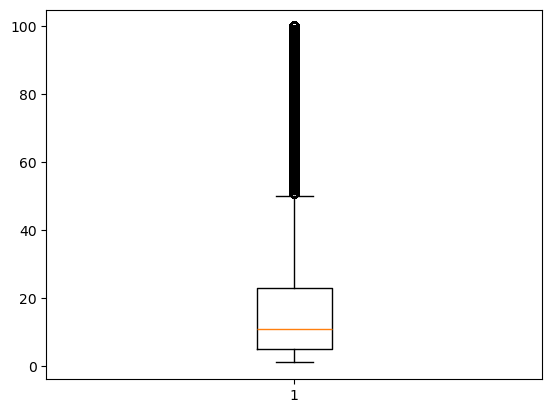

In [44]:
plt.boxplot(ordenes['order_number'])
plt.show()

In [45]:
# La base de la caja es el 25% -> Q1
# La linea naranja es el 50% -> Q2, Mediana 
# El techo de la caja es el 75% -> Q3

# IQR: Rango Interquartilico = Q3 - Q1

# Bigote Inferior = Q1 - 1.5*IQR
# Bigote Superior = Q3 + 1.5*IQR

In [46]:
stat_descr_ordenes = ordenes.describe()

In [47]:
stat_descr_ordenes.query('order_number == 23')

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
75%,2563002.25,154419.0,23.0,5.0,16.0,15.0


In [48]:
stat_descr_ordenes

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789520e+05,478952.000000,478952.000000,478952.000000,478952.000000,478952.000000
mean,1.709953e+06,102966.654911,17.157563,2.775051,13.447034,10.373687
std,9.869537e+05,59525.292863,17.704457,2.045901,4.224567,9.362489
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,-1.000000
25%,8.564698e+05,51413.750000,5.000000,1.000000,10.000000,4.000000
50%,1.709521e+06,102633.000000,11.000000,3.000000,13.000000,7.000000
75%,2.563002e+06,154419.000000,23.000000,5.000000,16.000000,15.000000
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.000000


In [49]:
# .iloc[indice, columna] busqueda por texto
stat_descr_ordenes.loc['75%', 'order_number']

23.0

In [50]:
stat_descr_ordenes.iloc[6, 2]

23.0

In [51]:
IQR = stat_descr_ordenes.loc['75%', 'order_number'] - stat_descr_ordenes.loc['25%', 'order_number']

In [52]:
limite_superior = stat_descr_ordenes.loc['75%', 'order_number'] + 1.5 * IQR

In [53]:
outliers_basados_boxplot = ordenes.query(f'order_number > {limite_superior}')

In [54]:
stat_descr_ordenes

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789520e+05,478952.000000,478952.000000,478952.000000,478952.000000,478952.000000
mean,1.709953e+06,102966.654911,17.157563,2.775051,13.447034,10.373687
std,9.869537e+05,59525.292863,17.704457,2.045901,4.224567,9.362489
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,-1.000000
25%,8.564698e+05,51413.750000,5.000000,1.000000,10.000000,4.000000
50%,1.709521e+06,102633.000000,11.000000,3.000000,13.000000,7.000000
75%,2.563002e+06,154419.000000,23.000000,5.000000,16.000000,15.000000
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.000000


In [55]:
sorted(ordenes.order_dow.unique())

[0, 1, 2, 3, 4, 5, 6]

In [56]:
sorted(ordenes.order_hour_of_day.unique())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23]

In [57]:
sorted(ordenes.days_since_prior_order.unique())

[-1.0,
 0.0,
 1.0,
 2.0,
 3.0,
 4.0,
 5.0,
 6.0,
 7.0,
 8.0,
 9.0,
 10.0,
 11.0,
 12.0,
 13.0,
 14.0,
 15.0,
 16.0,
 17.0,
 18.0,
 19.0,
 20.0,
 21.0,
 22.0,
 23.0,
 24.0,
 25.0,
 26.0,
 27.0,
 28.0,
 29.0,
 30.0]

In [58]:
# Practicar para su examen, los datos que tenemos son el universo de compras de esos clientes o es una muestra?

In [59]:
ordenes

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


---
## Distribuciones: Histogramas, KDE y Q-Q Plots

Las métricas descriptivas (media, SD, skew) son resúmenes numéricos de la distribución. El histograma y la KDE son su visualización completa. Ver la forma de la distribución revela patrones que los estadísticos numéricos ocultan: bimodalidad, concentraciones en valores específicos, la presencia de outliers en contexto.

### El histograma: frecuencias en intervalos

El histograma divide el rango de la variable en intervalos (bins) de igual ancho y muestra la frecuencia de observaciones en cada intervalo. La elección del número de bins afecta significativamente la interpretación: muy pocos bins suavizan los detalles, demasiados producen ruido visual.

**Reglas estándar para el número de bins:**
- Regla de Sturges: k = ⌈log₂(n)⌉ + 1 (adecuada para distribuciones normales)
- Regla de Rice: k = ⌈2n^(1/3)⌉ (más conservadora)
- Regla de Scott: ancho = 3.49σn^(−1/3) (óptima para normalidad)

### KDE — Kernel Density Estimation

La KDE estima la función de densidad de probabilidad subyacente superponiendo una función kernel (normalmente gaussiana) sobre cada observación. El resultado es una curva suave que representa la forma continua de la distribución, sin los artefactos de discretización del histograma.

La superposición de histograma y KDE es la visualización estándar porque combina la precisión de frecuencias del histograma con la suavidad interpretativa de la KDE. Las líneas verticales de media y mediana sobre esta visualización permiten diagnosticar la asimetría directamente.

### Patrones visuales clave

```
Simétrico (skew ≈ 0):      ▁▃▆█▆▃▁    media ≈ mediana
Cola derecha (skew+ > 0):  █▆▃▁▁▁▁    media > mediana (ingresos, tiempos)
Cola izquierda (skew- < 0):▁▁▁▁▃▆█    media < mediana
Bimodal:                   ▃█▃▁▃█▃    dos subpoblaciones mezcladas
Uniforme:                  ████████   igual frecuencia en todo el rango
```

### Q-Q Plot: verificación de normalidad

El Q-Q plot (Quantile-Quantile plot) compara los cuantiles empíricos de la variable con los cuantiles teóricos de una distribución normal de referencia. Si los puntos caen sobre la diagonal, la variable sigue una distribución normal.

**Interpretación de las desviaciones:**
- **Puntos sobre la diagonal:** los datos siguen la distribución de referencia
- **Cola superior arqueada hacia arriba:** cola derecha más pesada que la normal (skew+)
- **Cola inferior arqueada hacia abajo:** cola izquierda más pesada que la normal (skew-)
- **Forma de S:** bimodalidad o kurtosis diferente a la normal
- **Puntos individuales extremos:** outliers

### Transformaciones para normalizar distribuciones sesgadas

Cuando una variable tiene skewness fuerte (|skewness| > 1), algunos modelos que asumen normalidad se ven afectados. Las transformaciones estándar son:

| Distribución | Transformación | Cuándo aplicar |
|-------------|---------------|----------------|
| Cola derecha moderada | Raíz cuadrada √x | Skewness 0.5–1.5, valores ≥ 0 |
| Cola derecha fuerte | Logaritmo log(x+1) | Skewness > 1.5, valores ≥ 0 |
| Cola derecha muy fuerte | Box-Cox o Yeo-Johnson | Skewness extremo, acepta valores negativos |
| Cola izquierda | x² o x³ | Skewness negativo |

---

In [60]:
# Como se ven las ventas por dia? Que dia es el que mas vendo?

# Verlo en un grafico

In [61]:
# Agrupando por dia de venta

ordenes_por_dia = ordenes.groupby('order_dow')['order_id'].count()

In [62]:
ordenes_por_dia.index = ['Domingo', 'Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado']

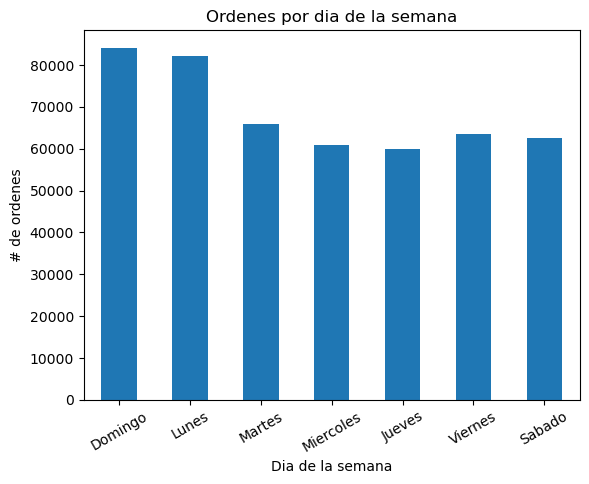

In [63]:
ordenes_por_dia.plot(kind='bar', title='Ordenes por dia de la semana', xlabel='Dia de la semana', ylabel='# de ordenes', rot=30)
plt.show()

In [64]:
ordenes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478952 non-null  int64  
 1   user_id                 478952 non-null  int64  
 2   order_number            478952 non-null  int64  
 3   order_dow               478952 non-null  int64  
 4   order_hour_of_day       478952 non-null  int64  
 5   days_since_prior_order  478952 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 25.6 MB


In [65]:
# Como se comportan las ventas por hora del dia?

ordenes.groupby('order_hour_of_day')['order_id'].count()

order_hour_of_day
0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_id, dtype: int64

In [66]:
# ordenes.groupby('order_hour_of_day')['user_id'].count()

In [67]:
ordenes_por_hora_del_dia = ordenes['order_hour_of_day'].value_counts().sort_index()

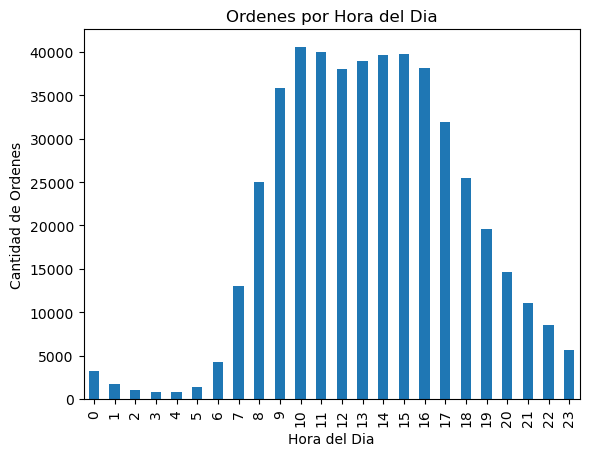

In [68]:
ordenes_por_hora_del_dia.plot(
    kind='bar',
    title='Ordenes por Hora del Dia',
    xlabel='Hora del Dia',
    ylabel='Cantidad de Ordenes',
)
plt.show()

In [69]:
# Ordenes por hora del domingo vs lunes

In [70]:
ordenes_por_hora_domingo = ordenes.query('order_dow == 0')['order_hour_of_day'].value_counts().sort_index()
ordenes_por_hora_lunes = ordenes.query('order_dow == 1')['order_hour_of_day'].value_counts().sort_index()

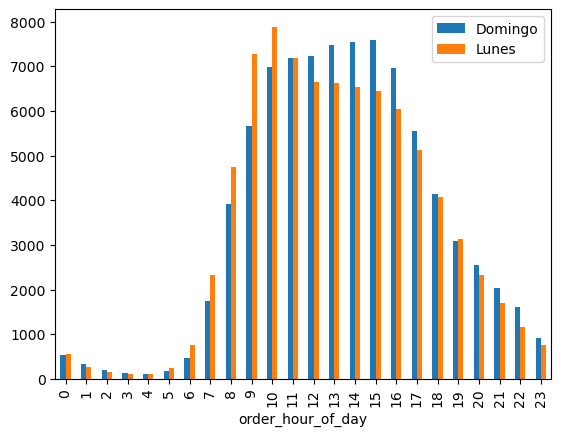

In [71]:
# Juntar datos en pandas: concat (alargamiento o engrosamiento por indice) vs merge (join por columna)

ordenes_hora_d_l = pd.concat([ordenes_por_hora_domingo, ordenes_por_hora_lunes], axis=1)
ordenes_hora_d_l.columns = ['Domingo', 'Lunes']

ordenes_hora_d_l.plot(
    kind='bar'
)

plt.show()

In [72]:
ordenes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 478952 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478952 non-null  int64  
 1   user_id                 478952 non-null  int64  
 2   order_number            478952 non-null  int64  
 3   order_dow               478952 non-null  int64  
 4   order_hour_of_day       478952 non-null  int64  
 5   days_since_prior_order  478952 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 25.6 MB


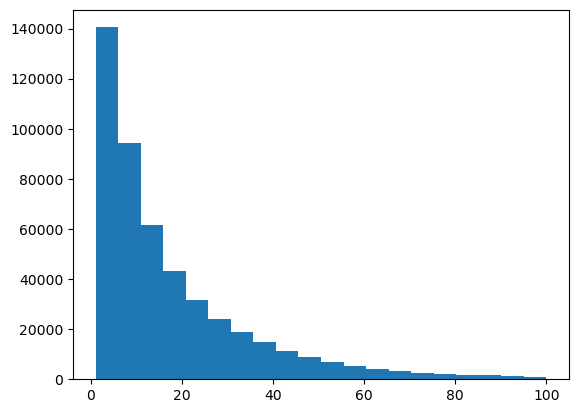

In [73]:
# Distribucion de los datos!
# Como se distribuyen las compras por cliente!

plt.hist(ordenes['order_number'], bins=20)
plt.show()

In [74]:
# Cual es la distribucion para el numero de compras por cliente?

ordenes_por_usuario = ordenes.groupby('user_id')['order_id'].count()

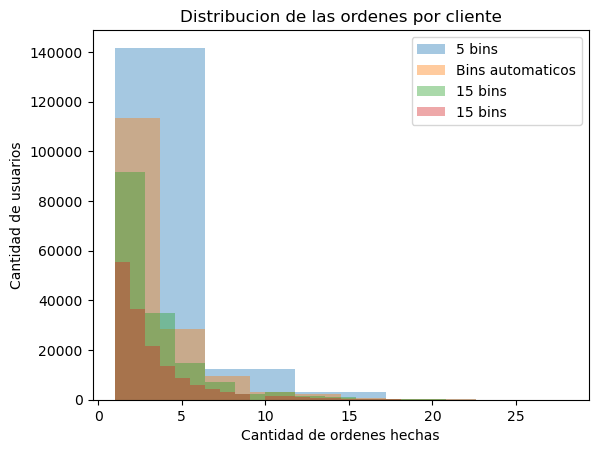

In [75]:
plt.hist(ordenes_por_usuario, bins=5, alpha=0.4, label='5 bins')
plt.hist(ordenes_por_usuario, alpha=0.4, label='Bins automaticos')
plt.hist(ordenes_por_usuario, bins=15, alpha=0.4, label='15 bins')
plt.hist(ordenes_por_usuario, bins=30, alpha=0.4, label='15 bins')
plt.legend()
plt.title('Distribucion de las ordenes por cliente')
plt.xlabel('Cantidad de ordenes hechas')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [76]:
# KDE: Kernel Density Estimation
# Es una tecnica que nos permite estimar como se distribuye una variable continua a partir de una muestra de la poblacion! NO ASUME UNA FORMA PREMEDITADAMENTE!
# En vez de hacer un histograma (donde dependemos de donde se pongan los bordes de las barras)
# Se coloca una curva pequeña suave encima de cada dato de la muestra (kernel), luego se suma todas las curvas y se promedian
# Me da como resultado una curva continua que representa la densidad de probabilidad estimada de la variable!

# Diferencias con un histograma:
# Discreto vs Continuo
# No depende de la cantidad de bins, ni de la posicion de los mismos.

# El KDE es una forma suavizada no parametrica de un histograma, sirve para estimar, explorar y visualizar la distribucion de una variable.

In [77]:
import seaborn as sns

In [78]:
ordenes_por_usuario.mean()

3.042181952145938

In [79]:
#sns.kdeplot(ordenes_por_usuario, fill=True, color='skyblue')

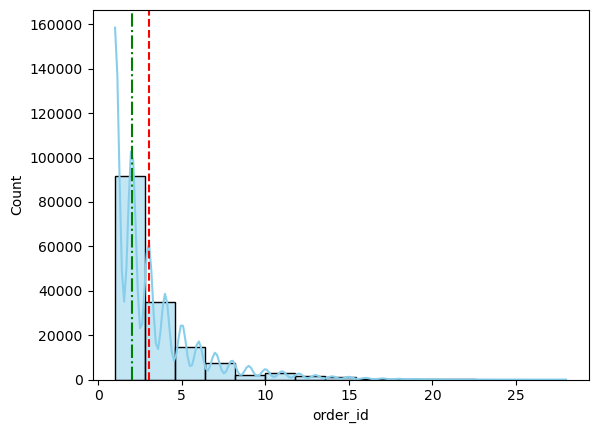

In [80]:
sns.histplot(ordenes_por_usuario, bins=15, kde=True, color='skyblue')
plt.axvline(ordenes_por_usuario.mean(), color='red', linestyle='--')
plt.axvline(ordenes_por_usuario.median(), color='green', linestyle='-.')
plt.show()

---
## Aplicación en Variables Dimensionales

Aplicando los mismos principios de calidad (completitud, precisión) en nuestras nuevas fuentes de datos (Productos y Detalles de Órdenes).

In [81]:
# Cuales son los 20 productos que mas me compran? (Nombre producto, ID)

# Traer los datos de productos
# EDA
# Calidad de datos: completitud, precision, consistencia y sensibilidad
# -> merge()
# -> groupby() -> cuentan() -> ordenan()


In [82]:
productos = pd.read_csv('datos/products.csv', sep=';')
ordenes_detalle = pd.read_csv('datos/order_products.csv', sep=';')

In [83]:
productos.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [84]:
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [85]:
productos.shape

(49694, 4)

In [86]:
productos.describe()

,product_id,aisle_id,department_id
count,49694.000000,49694.000000,49694.000000
mean,24847.500000,67.773192,11.728478
std,14345.566475,38.317265,5.850314
min,1.000000,1.000000,1.000000
25%,12424.250000,35.000000,7.000000
50%,24847.500000,69.000000,13.000000
75%,37270.750000,100.000000,17.000000
max,49694.000000,134.000000,21.000000


In [87]:
productos.isna().sum()

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

In [88]:
# 1. dejar los na
# 2. eliminar las filas
# 3. imputar ("Desconocido")

productos_con_nombre_faltante = productos[productos['product_name'].isna()]

In [89]:
productos_con_nombre_faltante

,product_id,product_name,aisle_id,department_id
37,38,NaN,100,21
71,72,NaN,100,21
109,110,NaN,100,21
296,297,NaN,100,21
416,417,NaN,100,21
...,...,...,...,...
49552,49553,NaN,100,21
49574,49575,NaN,100,21
49640,49641,NaN,100,21
49663,49664,NaN,100,21


In [90]:
productos_con_nombre_faltante['aisle_id'].unique()

array([100])

In [91]:
productos_con_nombre_faltante['department_id'].unique()

array([21])

In [92]:
productos['product_name'] = productos['product_name'].fillna('Nombre Desconocido')

In [93]:
productos.isna().sum()

product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

In [94]:
productos.duplicated().sum()

0

In [95]:
productos.duplicated(subset=['product_id']).sum()

0

In [96]:
productos['product_name'].str.lower().duplicated().sum()

1361

In [97]:
productos[productos['product_name'].str.lower().duplicated() & (productos['product_name'] != 'Nombre Desconocido')]

,product_id,product_name,aisle_id,department_id
2058,2059,Biotin 1000 Mcg,47,11
5455,5456,Green Tea With Ginseng and Honey,96,20
5558,5559,Cream Of Mushroom Soup,69,15
7558,7559,Cinnamon Rolls with Icing,105,13
9037,9038,American Cheese slices,21,16
...,...,...,...,...
49689,49690,HIGH PERFORMANCE ENERGY DRINK,64,7
49690,49691,ORIGINAL PANCAKE & WAFFLE MIX,130,14
49691,49692,ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR,130,14
49692,49693,SPRING WATER BODY WASH,127,11


In [98]:
ordenes_detalle.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17.0,0
1,567889,1560,1.0,1
2,2261212,26683,1.0,1
3,491251,8670,35.0,1
4,2571142,1940,5.0,1


In [99]:
ordenes_detalle.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


In [100]:
ordenes_detalle.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [101]:
ordenes_detalle[ordenes_detalle['add_to_cart_order'].isna()]

,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1
...,...,...,...,...
4505662,1800005,7411,NaN,0
4511400,1633337,260,NaN,0
4517562,404157,9517,NaN,0
4534112,1673227,17835,NaN,0


In [102]:
# Estas son las ordenes que tienen productos sin posicion del carrito de compras
ordenes_faltantes = ordenes_detalle[ordenes_detalle['add_to_cart_order'].isna()]['order_id']

In [103]:
ordenes_faltantes.value_counts()

order_id
61355      63
3308010    51
2136777    44
171934     40
1959075    34
           ..
888470      1
2621907     1
2729254     1
9310        1
2170451     1
Name: count, Length: 70, dtype: int64

In [104]:
ordenes_faltantes = ordenes_faltantes.unique()

In [105]:
full_detalle_ordenes_con_posicion_na = ordenes_detalle[ordenes_detalle['order_id'].isin(ordenes_faltantes)]

In [106]:
full_detalle_ordenes_con_posicion_na['order_id'].value_counts()

order_id
61355      127
3308010    115
2136777    108
171934     104
1959075     98
          ... 
1598369     65
2652650     65
2621907     65
888470      65
2170451     65
Name: count, Length: 70, dtype: int64

In [107]:
# Conclusion

# De todas las ordenes que no tienen productos con posicion en el carrito, TODAS superan los 64 items de compra
# Es esto un bug del sistema?????

In [108]:
full_detalle_ordenes_con_posicion = ordenes_detalle[~ordenes_detalle['order_id'].isin(ordenes_faltantes)]

In [109]:
full_detalle_ordenes_con_posicion['order_id'].value_counts()

order_id
989476     64
1007609    64
1149773    64
750981     64
3062914    64
           ..
3009357     1
2535899     1
2904455     1
2124536     1
1461911     1
Name: count, Length: 449976, dtype: int64

In [110]:
ordenes_detalle['add_to_cart_order'] = ordenes_detalle['add_to_cart_order'].fillna(-1).astype('int')

In [111]:
# Efectivamente, se comprueba que al superar los 64 productos en el carrito, las posiciones dejan de ser capturadas!!!! y son ausentes!

In [112]:
#ordenes_detalle['add_to_cart_order'] = ordenes_detalle['add_to_cart_order'].astype(int)

In [113]:
islas = pd.read_csv('./datos/aisles.csv', sep=';')
departamentos = pd.read_csv('./datos/departments.csv', sep=';')

In [114]:
islas.query('aisle_id == 100')

,aisle_id,aisle
99,100,missing


In [115]:
departamentos.query('department_id == 21')

,department_id,department
20,21,missing


In [116]:
ordenes_detalle.head()

,order_id,product_id,add_to_cart_order,reordered
0,2141543,11440,17,0
1,567889,1560,1,1
2,2261212,26683,1,1
3,491251,8670,35,1
4,2571142,1940,5,1


In [117]:
# EDA, LIMPIEZA
# TO-DO de ambas

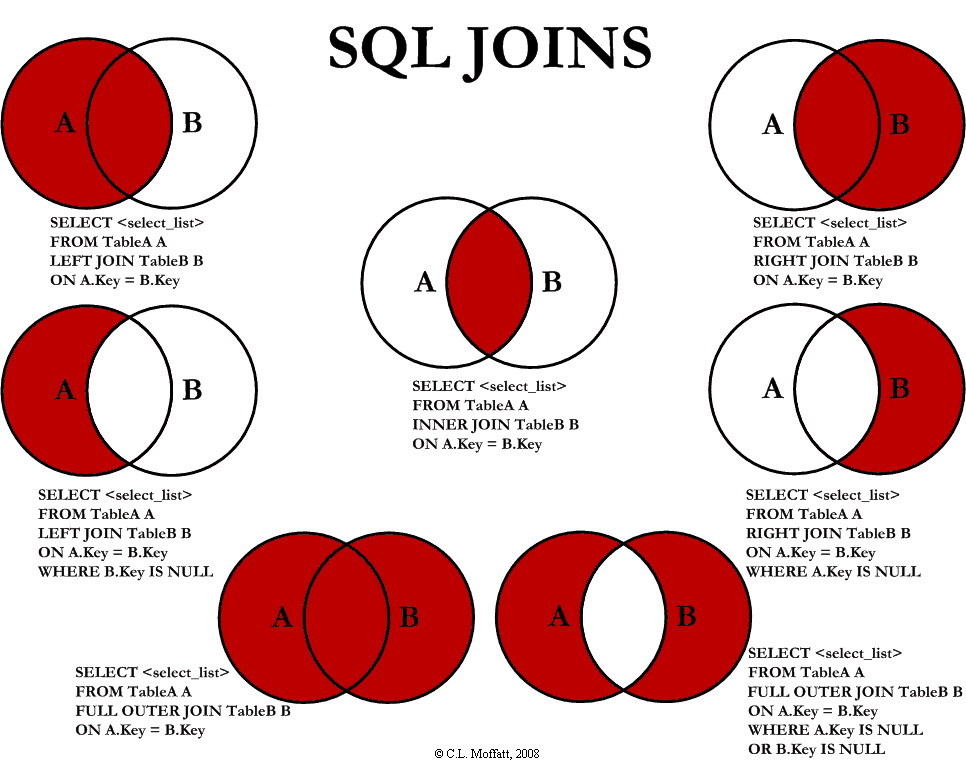

In [118]:
ordenes_full = ordenes_detalle.merge(productos, on='product_id', how='inner')

In [119]:
ordenes_full

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,2141543,11440,17,0,Chicken Breast Tenders Breaded,129,1
1,147172,11440,7,1,Chicken Breast Tenders Breaded,129,1
2,3341719,11440,4,1,Chicken Breast Tenders Breaded,129,1
3,1938779,11440,8,1,Chicken Breast Tenders Breaded,129,1
4,1728338,11440,23,0,Chicken Breast Tenders Breaded,129,1
...,...,...,...,...,...,...,...
4545002,267402,45226,14,0,Sweet Teriyaki Chicken Oven Sauce,5,13
4545003,2621676,25201,10,0,Crisp Waters Candle Scents,101,17
4545004,937623,49153,2,0,Shine Collection Brillance Shampoo,22,11
4545005,532895,8182,1,0,Total Mint Stripe Gel Toothpaste,20,11


In [120]:
top_20_productos = ordenes_full.groupby(['product_id', 'product_name'])['order_id'].count().sort_values(ascending=False).head(20)

In [121]:
top_20_productos = top_20_productos.reset_index()

In [122]:
top_20_productos.rename(columns={'order_id': 'num_ordenes'}, inplace=True)

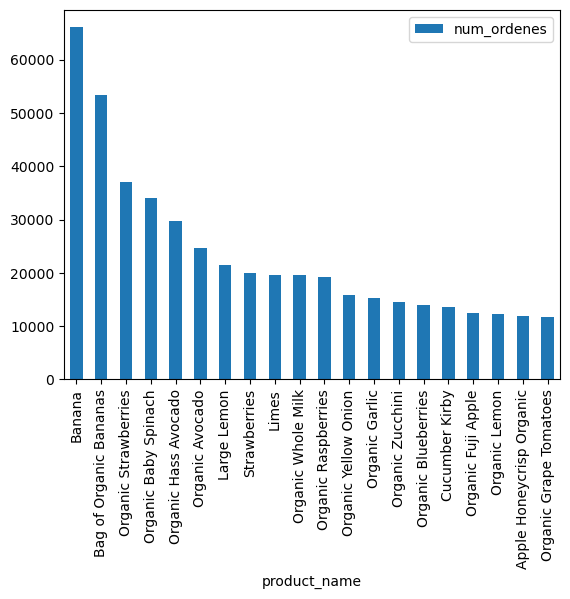

In [123]:
top_20_productos.plot(kind='bar', x='product_name', y='num_ordenes')
plt.show()

In [124]:
#Lanzar grafico donde los nombres estan en el eje vertical (y)
plt.show()

In [125]:
ordenes_full

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,2141543,11440,17,0,Chicken Breast Tenders Breaded,129,1
1,147172,11440,7,1,Chicken Breast Tenders Breaded,129,1
2,3341719,11440,4,1,Chicken Breast Tenders Breaded,129,1
3,1938779,11440,8,1,Chicken Breast Tenders Breaded,129,1
4,1728338,11440,23,0,Chicken Breast Tenders Breaded,129,1
...,...,...,...,...,...,...,...
4545002,267402,45226,14,0,Sweet Teriyaki Chicken Oven Sauce,5,13
4545003,2621676,25201,10,0,Crisp Waters Candle Scents,101,17
4545004,937623,49153,2,0,Shine Collection Brillance Shampoo,22,11
4545005,532895,8182,1,0,Total Mint Stripe Gel Toothpaste,20,11


---
## Covarianza, Correlación y Relaciones entre Variables

Hasta la sección anterior analizamos cada variable en solitario (análisis univariado). El paso final del EDA explora las relaciones entre pares de variables: ¿cuáles se mueven juntas?, ¿cuáles se oponen?, ¿qué variables predicen mejor la variable objetivo? La covarianza mide la dirección, la correlación mide la fuerza y la dirección, normalizadas por las escalas individuales.

### Covarianza — la relación sin escala

**Definición:** Cov(X,Y) = Σ(xᵢ − x̄)(yᵢ − ȳ) / (n−1)

La covarianza mide si dos variables se mueven en la misma dirección (covarianza positiva) o en direcciones opuestas (covarianza negativa). Un valor de cero indica ausencia de relación lineal.

**Limitación fundamental:** el valor de la covarianza depende de las unidades de medición de ambas variables. La covarianza entre ingresos (en dólares) y edad (en años) no es comparable con la covarianza entre ingresos (en miles de dólares) y edad (en meses), aunque representen la misma relación. Esto hace imposible la comparación directa entre pares de variables distintas.

### Correlación de Pearson — fuerza y dirección normalizadas

**Definición:** r = Cov(X,Y) / (σ_X · σ_Y)    →    rango [−1, 1]

La correlación de Pearson normaliza la covarianza por las desviaciones estándar de ambas variables, produciendo un estadístico sin unidades que siempre cae en el rango [−1, 1]:

- **r = +1:** correlación lineal perfecta positiva
- **r = −1:** correlación lineal perfecta negativa
- **r = 0:** ausencia de correlación lineal
- **|r| < 0.3:** correlación débil
- **0.3 ≤ |r| < 0.7:** correlación moderada
- **|r| ≥ 0.7:** correlación fuerte

**Supuestos de Pearson:** variables numéricas, relación lineal, distribuciones aproximadamente normales, ausencia de outliers influyentes. Cuando estos supuestos no se cumplen, Pearson puede subestimar o sobreestimar la fuerza de la relación.

### Correlación de Spearman — no paramétrica

La correlación de Spearman calcula la correlación de Pearson sobre los rangos de los datos en lugar de los valores originales. Mide relaciones monotónicas (donde X siempre sube cuando Y sube, aunque no sea una relación lineal exacta) y es robusta a outliers.

Cuando Pearson y Spearman difieren significativamente, es una señal de que la relación es monotónica pero no lineal, o de que hay outliers que distorsionan a Pearson.

### El heatmap de correlaciones

La matriz de correlaciones, visualizada como un heatmap de color, es la herramienta estándar para explorar relaciones simultáneas entre múltiples variables. Los colores más intensos (rojo para correlaciones positivas fuertes, azul para negativas fuertes) guían la atención hacia las relaciones más relevantes.

La diagonal principal siempre es 1 (una variable correlaciona perfectamente consigo misma). La matriz es simétrica respecto a la diagonal.

### La advertencia más importante: correlación ≠ causalidad

La correlación entre dos variables puede originarse por cuatro mecanismos distintos:

1. **Causalidad directa:** A causa B
2. **Causalidad inversa:** B causa A
3. **Variable confusora:** una tercera variable C causa tanto A como B simultáneamente
4. **Coincidencia estadística:** correlaciones espurias en muestras pequeñas o por azar

El ejemplo clásico: el número de bomberos presentes en un incendio correlaciona positivamente con el daño causado. No significa que los bomberos causen el daño: la variable confusora es el tamaño del incendio, que determina simultáneamente cuántos bomberos se envían y cuánto daño ocurre.

En ciencia de datos, la inferencia causal requiere diseño experimental, variables instrumentales u otros métodos específicos. El EDA solo revela asociaciones, no causas.

---

In [126]:
# Hay alguna relacion entre las variables
# Metrica 1: Co-varianza
# Mide: si dos variables se mueven juntas, y en que direccion!
# Problema: Es sensible a la escala de las variables, es complicado comparar (interpretar)


In [127]:
# X , Y
# [SUMA i=1 -> n ((Xi - Xpromedio)(Yi - Ypromedio))] / n

In [ ]:
# Corelacion de Pearson

#r = Cov(X,Y) / sigma_X * sigma_Y

# Existe en el espacio de {-1, 1}

In [130]:
ordenes_full.corr(numeric_only=True)

,order_id,product_id,add_to_cart_order,reordered,aisle_id,department_id
order_id,1.000000,-0.001067,0.000996,0.000705,0.000303,-0.000007
product_id,-0.001067,1.000000,0.006352,0.003196,0.002481,-0.027165
add_to_cart_order,0.000996,0.006352,1.000000,-0.133297,0.009721,0.027734
reordered,0.000705,0.003196,-0.133297,1.000000,0.004326,-0.039268
aisle_id,0.000303,0.002481,0.009721,0.004326,1.000000,0.062569
department_id,-0.000007,-0.027165,0.027734,-0.039268,0.062569,1.000000


In [ ]:
# Grafico de dispersion: permite ver la relacion en 2 dimensiones de 2 variables

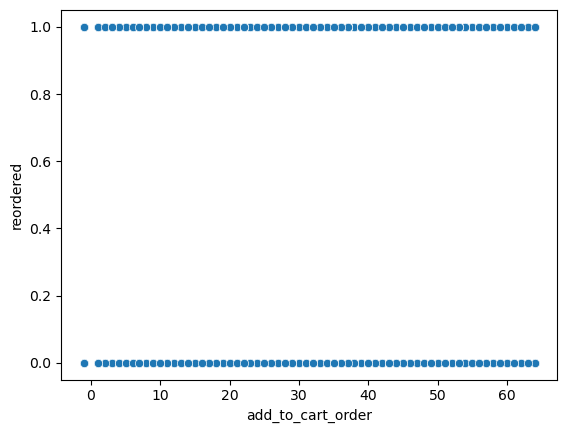

In [131]:
sns.scatterplot(data=ordenes_full, x='add_to_cart_order', y='reordered')
plt.show()

In [ ]:
# Por cliente, cuantos productos compran, cuantos recompran, ratio de recompra

In [134]:
ordenes_full

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id
0,2141543,11440,17,0,Chicken Breast Tenders Breaded,129,1
1,147172,11440,7,1,Chicken Breast Tenders Breaded,129,1
2,3341719,11440,4,1,Chicken Breast Tenders Breaded,129,1
3,1938779,11440,8,1,Chicken Breast Tenders Breaded,129,1
4,1728338,11440,23,0,Chicken Breast Tenders Breaded,129,1
...,...,...,...,...,...,...,...
4545002,267402,45226,14,0,Sweet Teriyaki Chicken Oven Sauce,5,13
4545003,2621676,25201,10,0,Crisp Waters Candle Scents,101,17
4545004,937623,49153,2,0,Shine Collection Brillance Shampoo,22,11
4545005,532895,8182,1,0,Total Mint Stripe Gel Toothpaste,20,11


In [135]:
ordenes_full = ordenes_full.merge(ordenes, how='inner', on='order_id')

In [142]:
# OBT: One Big Table

analisis_de_compras_por_usuario = ordenes_full.groupby('user_id')[['product_id', 'order_id']].nunique()

In [144]:
analisis_de_compras_por_usuario.columns = ['num_productos', 'num_ordenes']

In [145]:
analisis_de_compras_por_usuario.corr()

,num_productos,num_ordenes
num_productos,1.000000,0.682434
num_ordenes,0.682434,1.000000


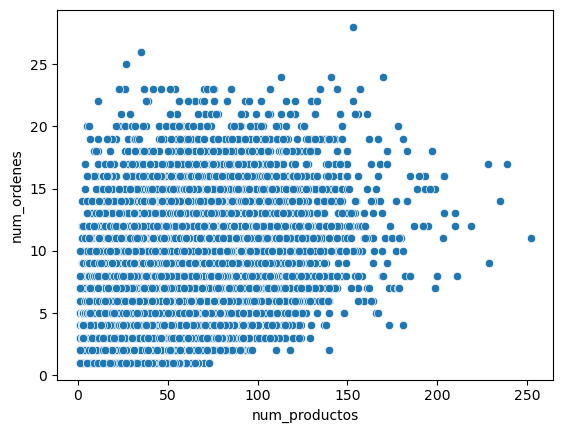

In [146]:
sns.scatterplot(data=analisis_de_compras_por_usuario, x='num_productos', y='num_ordenes')
plt.show()

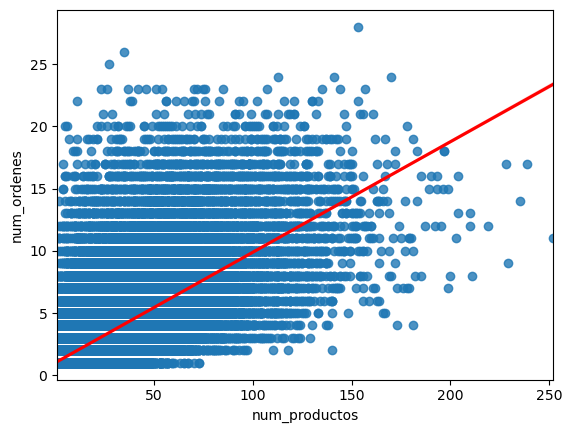

In [148]:
sns.regplot(data=analisis_de_compras_por_usuario, x='num_productos', y='num_ordenes', scatter=True, line_kws={'color': 'red'})
plt.show()

---
## Resumen
El EDA no termina con el análisis: termina con el reporte. Un EDA bien documentado registra qué se encontró, qué decisiones se tomaron, por qué se tomaron, y qué incertidumbres persisten. Este registro es el contrato de confianza con los datos que permite reproducir el análisis y justificar las decisiones de preprocesamiento ante cualquier audiencia técnica o de negocio.

### Documentar las decisiones del wrangling

Cada decisión de data wrangling tiene consecuencias que se propagan a todo el análisis posterior. Imputar con mediana en lugar de media, capped outliers en lugar de eliminarlos, usar MICE en lugar de KNN — cada una de estas decisiones afecta las distribuciones, las correlaciones y el comportamiento de los modelos. Sin documentación, estas decisiones se vuelven invisibles y no auditables.

El estándar profesional es mantener un registro de decisiones de preprocesamiento que incluya para cada acción: qué se hizo, sobre qué variable, con qué método, por qué se eligió ese método, y cuántos registros se afectaron.

### El checklist del EDA riguroso

**Exploración inicial**
- Dimensiones, tipos, estructura y estadísticos básicos verificados
- Muestra aleatoria inspeccionada (no solo primeras filas)
- Granularidad del dataset confirmada y apropiada para el análisis

**Calidad — Completitud**
- Proporción de valores ausentes por columna cuantificada
- Mecanismo de ausencia evaluado (MCAR/MAR/MNAR) con evidencia
- Estrategia de imputación seleccionada y justificada por mecanismo
- Variables indicadoras de missingness creadas donde corresponde

**Calidad — Precisión**
- Duplicados exactos detectados y eliminados
- Tricky duplicates verificados en variables clave de identificación
- Duplicados funcionales evaluados según la granularidad correcta

**Calidad — Sensibilidad**
- Rangos plausibles definidos con conocimiento del dominio
- Outliers detectados con IQR y/o Z-score (ambos complementarios)
- Outliers clasificados: error de ingesta vs. valor legítimo inusual
- Estrategia de tratamiento aplicada y documentada para cada caso

**Calidad — Consistencia**
- Tipos computacionales corregidos para corresponder a tipos estadísticos
- Variables categóricas codificadas apropiadamente
- Formatos de fecha y hora normalizados

**Análisis estadístico**
- Tendencia central (media, mediana, moda) calculada por variable
- Variabilidad (SD, CV, IQR) evaluada por variable
- Forma (skewness, kurtosis) interpretada para cada distribución
- Histogramas y KDE generados para todas las variables numéricas
- Q-Q plots interpretados para evaluar supuesto de normalidad
- Correlaciones calculadas (Pearson y Spearman como mínimo)
- Heatmap de correlaciones inspeccionado para patrones relevantes
- Correlaciones con la variable objetivo identificadas y ordenadas

### Preguntas que el EDA debe responder

1. **¿Qué es este dataset?** — granularidad, número de registros, fuente, período cubierto
2. **¿Tiene problemas de calidad?** — completitud, precisión, sensibilidad, consistencia
3. **¿Cómo se comportan las variables?** — distribuciones, estadísticos, outliers
4. **¿Qué variables se relacionan entre sí?** — correlaciones, patrones bivariados
5. **¿Está listo para modelado?** — decisiones tomadas, limitaciones conocidas, próximos pasos

### EDA a Data Wrangling

```
Datos crudos — confianza: desconocida
       ↓
Exploración inicial → comprender la estructura del dataset
       ↓
Auditoría de calidad → identificar problemas en 4 dimensiones
       ↓
Data wrangling → resolver problemas con evidencia y criterio
       ↓
Datos limpios — confianza: alta, documentada
       ↓
Análisis estadístico riguroso → tendencia central, dispersión, forma
       ↓
Análisis de relaciones → correlaciones, patrones bivariados
       ↓
Dataset auditado, documentado y listo para modelado ML
```

La distinción fundamental es que el análisis estadístico riguroso — las medidas de tendencia central, variabilidad, skewness, distribuciones y correlaciones — solo tiene validez científica cuando se aplica sobre datos que han pasado por el proceso de auditoría y wrangling. Calcular la media de una variable con outliers espurios, valores ausentes no tratados o tipos incorrectos produce un número que carece de significado real, aunque sea matemáticamente correcto.